In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy


In [2]:
pd.set_option('display.max_rows', 10)

In [3]:

# Load the data
# Datasets describing the pollutants and meteorological data
# from 2020 to 2023
meteo2020_df = pd.read_csv('Data/KTZH_00002383_00005465.csv')
meteo2021_df = pd.read_csv('Data/KTZH_00002383_00005466.csv')
meteo2022_df = pd.read_csv('Data/KTZH_00002383_00005467.csv')
meteo2023_df = pd.read_csv('Data/KTZH_00002383_00005468.csv')

# Datasets describing the number-size distribution of the particles
# from 2020 to 2023
particles2020_df = pd.read_csv('Data/KTZH_00002383_00005469.csv')
particles2021_df = pd.read_csv('Data/KTZH_00002383_00005470.csv')
particles2022_df = pd.read_csv('Data/KTZH_00002383_00005471.csv')
particles2023_df = pd.read_csv('Data/KTZH_00002383_00005472.csv')

In [4]:
def convert_to_datetime(df, startime_col):
    """
    Convert the starttime column to a datetime format.
    """
    df[startime_col] = pd.to_datetime(df[startime_col]) 
    # remove the timezone information
    df[startime_col] = df[startime_col].dt.tz_localize(None)
    return df

all_dataframes = [meteo2020_df, meteo2021_df, meteo2022_df, meteo2023_df,
                  particles2020_df, particles2021_df, particles2022_df, particles2023_df]
# Convert the starttime column to a datetime format in all dataframes
for df in all_dataframes:
    if 'starttime' in df.columns:
        df = convert_to_datetime(df, 'starttime')
    else:
        raise ValueError("No starttime column found in dataframe")

In [5]:
particles2020_df

,starttime,dp,parameter,value
0,2020-02-29 00:00:00,4.96,dN,317.782275
1,2020-02-29 00:00:00,5.14,dN,228.808446
2,2020-02-29 00:00:00,5.33,dN,346.173648
3,2020-02-29 00:00:00,5.52,dN,207.719798
4,2020-02-29 00:00:00,5.73,dN,174.466491
...,...,...,...,...
7515355,2020-12-31 23:50:00,88.17,dN/dlogDp,26491.549316
7515356,2020-12-31 23:50:00,91.40,dN/dlogDp,29154.467155
7515357,2020-12-31 23:50:00,94.75,dN/dlogDp,28427.521440
7515358,2020-12-31 23:50:00,98.22,dN/dlogDp,27085.203897


In [6]:
df_all = pd.concat([particles2020_df, particles2021_df, particles2022_df, particles2023_df], ignore_index=True)

df_all.set_index('starttime', inplace=True)

df_all['year'] = df_all.index.year

display(df_all)

,dp,parameter,value,year
starttime,,,,
2020-02-29 00:00:00,4.96,dN,317.782275,2020
2020-02-29 00:00:00,5.14,dN,228.808446,2020
2020-02-29 00:00:00,5.33,dN,346.173648,2020
2020-02-29 00:00:00,5.52,dN,207.719798,2020
2020-02-29 00:00:00,5.73,dN,174.466491,2020
...,...,...,...,...
2023-12-31 23:50:00,88.17,dN/dlogDp,5453.338246,2023
2023-12-31 23:50:00,91.40,dN/dlogDp,5811.566946,2023
2023-12-31 23:50:00,94.75,dN/dlogDp,5726.849802,2023


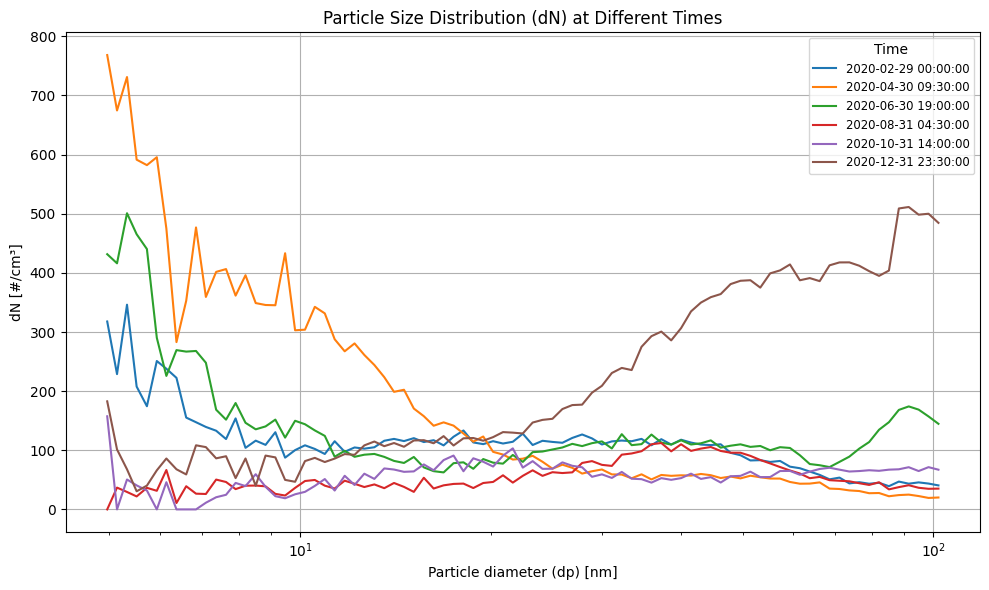

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = particles2020_df

# Select a few timestamps
# Get unique timestamps, sort them, and pick a few spaced across the day
unique_times = sorted(df['starttime'].unique())
selected_times = unique_times[::len(unique_times)//5]  # Pick 5 evenly spaced times

# Filter data for a specific parameter ('dN' or 'dN/dlogDp')
parameter = 'dN'
df_filtered = df[df['parameter'] == parameter]

# Step 5: Plot size distribution for each selected time
plt.figure(figsize=(10, 6))

for time in selected_times:
    subset = df_filtered[df_filtered['starttime'] == time]
    # Sort by particle size
    subset = subset.sort_values(by='dp')
    plt.plot(subset['dp'], subset['value'], label=str(time))

plt.xscale('log')
plt.xlabel('Particle diameter (dp) [nm]')
plt.ylabel(f'{parameter} [#/cm³]')
plt.title(f'Particle Size Distribution ({parameter}) at Different Times')
plt.legend(title='Time', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


Question: What is the difference between 'dN' and 'dN/dlogDp'?

In [8]:
# Create two separate dataframes, filtering for each of the parameters
df_dn = df_all[df_all['parameter'] == 'dN'].copy()
df_dndl = df_all[df_all['parameter'] == 'dN/dlogDp'].copy()



# we don't need the parameter column in these two dataframes anymore
df_dn.drop(columns='parameter', inplace=True)
df_dndl.drop(columns='parameter', inplace=True)
display(df_dn)
display(df_dndl)

,dp,value,year
starttime,,,
2020-02-29 00:00:00,4.96,317.782275,2020
2020-02-29 00:00:00,5.14,228.808446,2020
2020-02-29 00:00:00,5.33,346.173648,2020
2020-02-29 00:00:00,5.52,207.719798,2020
2020-02-29 00:00:00,5.73,174.466491,2020
...,...,...,...
2023-12-31 23:50:00,88.17,85.208410,2023
2023-12-31 23:50:00,91.40,90.805734,2023
2023-12-31 23:50:00,94.75,89.482028,2023


,dp,value,year
starttime,,,
2020-02-29 00:00:00,4.96,20338.065617,2020
2020-02-29 00:00:00,5.14,14643.740543,2020
2020-02-29 00:00:00,5.33,22155.113481,2020
2020-02-29 00:00:00,5.52,13294.067065,2020
2020-02-29 00:00:00,5.73,11165.855402,2020
...,...,...,...
2023-12-31 23:50:00,88.17,5453.338246,2023
2023-12-31 23:50:00,91.40,5811.566946,2023
2023-12-31 23:50:00,94.75,5726.849802,2023


In [9]:
print(df_dn['dp'].nunique())
print(df_dn.index.nunique())
print(df_dn.shape[0]/df_dn.index.nunique())

85
201888
85.0


For each date, there are exactly 85 different classes of particle size

In [10]:
df_dn_pivot = df_dn.pivot(columns='dp', values='value')
display(df_dn_pivot)

dp,4.96,5.14,5.33,5.52,5.73,5.94,6.15,6.38,6.61,6.85,...,73.65,76.35,79.15,82.05,85.05,88.17,91.40,94.75,98.22,101.82
starttime,,,,,,,,,,,,,,,,,,,,,
2020-02-29 00:00:00,317.782275,228.808446,346.173648,207.719798,174.466491,250.947303,237.869270,222.472360,155.260534,147.413275,...,43.975936,45.994587,43.406938,44.958390,39.252972,47.046487,43.496965,45.701937,43.692797,40.588092
2020-02-29 00:10:00,626.197097,670.743937,503.094747,651.863619,525.734735,506.464423,389.432846,353.013779,370.545318,321.753130,...,53.525643,42.384520,42.576177,44.353706,39.403139,41.775099,45.969593,44.943470,43.838474,39.205969
2020-02-29 00:20:00,493.354193,404.609599,530.940530,289.708394,208.808898,319.015935,394.797841,257.050977,244.954087,397.198914,...,54.614633,49.861137,44.734492,42.120128,40.540355,42.790903,50.013082,43.876268,44.216870,35.972076
2020-02-29 00:30:00,279.919197,524.808866,447.823345,466.168408,289.447841,366.155080,288.945750,287.924653,296.152528,320.248395,...,47.694867,45.397678,42.008983,41.326533,41.137361,44.150002,42.427758,41.626343,37.085138,38.830498
2020-02-29 00:40:00,173.274068,415.498651,249.287679,470.731890,234.676018,198.003669,423.817772,218.372745,280.801204,229.285857,...,52.564034,50.885392,41.337755,46.598353,44.056750,50.114612,46.507512,47.435364,45.332339,44.306451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 23:10:00,26.689588,136.295577,68.645782,116.267035,67.677175,66.602552,53.868387,65.859230,55.769992,49.007355,...,39.188144,40.058689,42.082771,46.263673,54.262143,52.357570,57.281936,53.298518,55.007739,61.082631
2023-12-31 23:20:00,100.248144,53.639178,88.436823,38.052467,63.500503,30.769402,62.443358,65.433683,47.528186,40.751911,...,40.111116,36.294332,38.696056,32.892075,42.774021,46.642810,39.007803,36.898379,39.922122,37.840037
2023-12-31 23:30:00,0.000000,0.000000,0.000000,54.179692,36.139110,32.264891,22.548727,27.660741,32.073252,54.982962,...,42.708583,38.919227,33.329770,38.687668,41.604100,48.998445,46.613197,40.023852,45.690037,39.385418


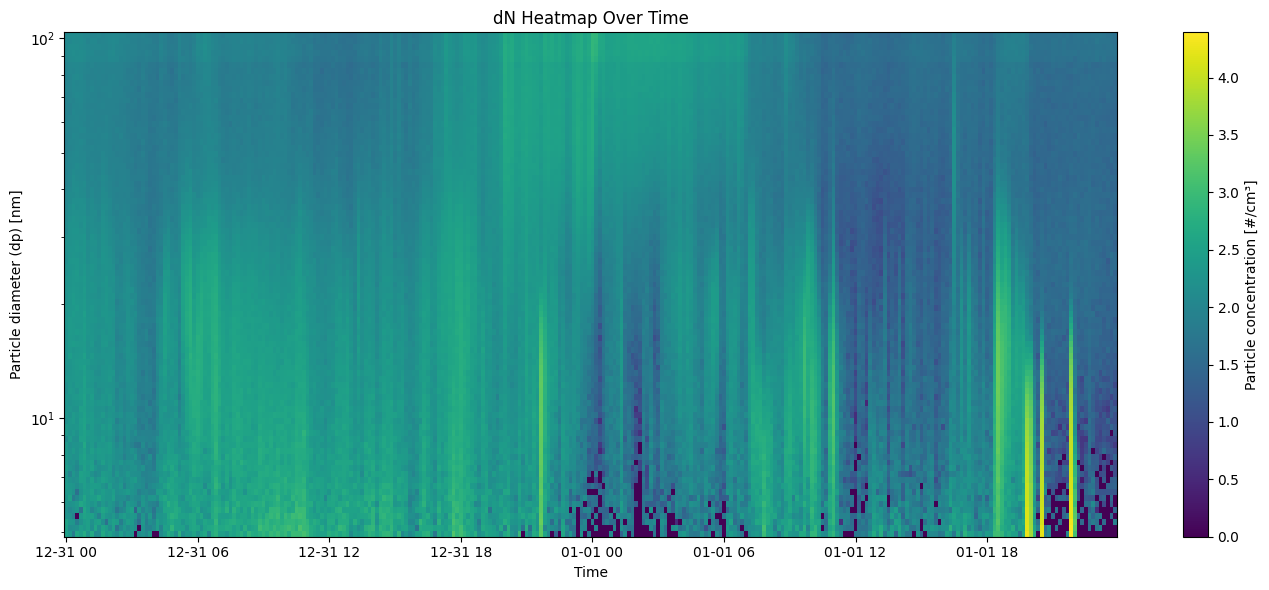

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



# 2. Optional: Filter to a smaller time window (e.g., 2 days) for clarity
start = "2020-12-31"
end = "2021-01-02"
mask = (df_dn.index >= start) & (df_dn.index < end)
df_dn_mask = df_dn[mask]
df_dn_reset = df_dn_mask.reset_index()
# 3. Pivot to get dp vs. time matrix
heatmap_data = df_dn_reset.pivot_table(index='dp', columns='starttime', values='value')

# 4. Sort index/columns to make sure they are ordered properly
heatmap_data = heatmap_data.sort_index().sort_index(axis=1)

# 5. Plot heatmap
plt.figure(figsize=(14, 6))
X, Y = np.meshgrid(
    pd.to_datetime(heatmap_data.columns).astype('datetime64[ns]'),
    heatmap_data.index.values
)
Z = np.log10(heatmap_data.values + 1)
# Z = heatmap_data.values
plt.pcolormesh(X, Y, Z, shading='auto', cmap='viridis')

plt.yscale('log')  # particle sizes are better on a log scale
plt.colorbar(label='Particle concentration [#/cm³]')
# plt.colorbar(label='log (Particle concentration [#/cm³])')
plt.xlabel('Time')
plt.ylabel('Particle diameter (dp) [nm]')
plt.title(f'{parameter} Heatmap Over Time')
plt.tight_layout()
plt.show()


In [12]:

import plotly.graph_objects as go
from ipywidgets import interact, widgets
from datetime import datetime

# Assuming df_dn is already filtered for 'dN' and has 'starttime' as index
# Reset index so 'starttime' becomes a column again
df_all_reset = df_all.reset_index()
# df_dn_reset = df_dn.reset_index()

# Available date range
min_date = df_all_reset['starttime'].min().date()
max_date = df_all_reset['starttime'].max().date()

# Interactive widgets
start_widget = widgets.DatePicker(description='Start Date', value=min_date)
end_widget = widgets.DatePicker(description='End Date', value=max_date)
param_widget = widgets.Dropdown(
    options=['dN', 'dN/dlogDp'],
    value='dN',
    description='Parameter'
)

# Interactive function
def plot_heatmap(start_date, end_date):
    if start_date is None or end_date is None:
        print("Please select both start and end dates.")
        return

    # Filter by parameter and time range
    df_param = df_all_reset[df_all_reset['parameter'] == parameter]
    mask = (df_all_reset['starttime'].dt.date >= start_date) & (df_all_reset['starttime'].dt.date <= end_date)
    df_filtered = df_all_reset[mask]

    if df_filtered.empty:
        print("No data in selected range.")
        return

    # Pivot for heatmap
    heatmap_data = df_filtered.pivot_table(index='dp', columns='starttime', values='value')
    heatmap_data = heatmap_data.sort_index().sort_index(axis=1)

    # Create log-transformed Z
    Z = np.log10(heatmap_data.values + 1)

    fig = go.Figure(data=go.Heatmap(
        z=Z,
        x=heatmap_data.columns,
        y=heatmap_data.index,
        colorscale='Viridis',
        colorbar=dict(title='log₁₀(concentration + 1)'),
    ))

    fig.update_layout(
        title=f"log-transformed particle concentrations from {start_date} to {end_date}",
        xaxis_title='Time',
        yaxis_title='Particle diameter (dp) [nm]',
        yaxis_type='log',
        height=600,
    )

    fig.show()

# Display interactive widget
interact(plot_heatmap, start_date=start_widget, end_date=end_widget);


interactive(children=(DatePicker(value=datetime.date(2020, 2, 29), description='Start Date', step=1), DatePick…